<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
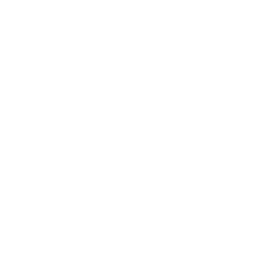
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Split-Plot Design for Process Optimization</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Quality Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook analyzes a split-plot designed experiment for an injection molding process. The whole-plot factor is **machine** (4 levels: MACH_A-MACH_D), which is hard to change, and the sub-plot factor is **speed setting** (5 levels: 60, 80, 100, 120, 140 RPM), which is easy to change. The experiment uses five whole-plot replicates with five sub-plot measurements each, giving **25 replicate readings per machine x speed cell and 500 defect-rate observations** in total.

`PROC MIXED` fits the restricted-randomization structure correctly by treating **machine as a random effect** (the whole-plot error stratum) and **speed as a fixed effect** (the sub-plot factor). The analysis estimates the two variance components, tests the speed effect, and produces Tukey-adjusted pairwise comparisons of the speed least-squares means to identify the operating speed that minimizes defect rate. The fitted model finds machine and residual variance components of comparable size (machine 3.78, residual 3.26), a highly significant speed effect (F(4, 492) = 131.51, p < .0001), and a clear quadratic speed response with the lowest defect rate at **100 RPM (LS-mean 7.71%)**.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Split-plot experimental data: 4 machines x 5 speeds x 25 replicate readings (5 whole-plot x 5 sub-plot) | 500 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic split-plot injection molding data
   4 machines (whole-plot) x 5 speeds (sub-plot) x 5 reps
   Additional replicates for each whole-plot
   -------------------------------------------------------- */
data work.molding_experiment;
    call streaminit(42);
    array machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    array speed_settings[5] _temporary_ (60 80 100 120 140);
    /* True machine effects (random) */
    array mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* True speed effects (fixed, quadratic with optimum ~100) */
    array speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    do whole_plot = 1 to 5;
        do m = 1 to 4;
            machine = machine_names[m];
            machine_id = cat('WP_', put(whole_plot, z2.), '_', machine);
            /* Whole-plot replicate effect */
            wp_noise = rand('normal', 0, 1.5);
            do s = 1 to 5;
                speed = speed_settings[s];
                speed_label = cat(put(speed, 3.), 'RPM');
                /* Sub-plot replicates within each whole-plot */
                do rep = 1 to 5;
                    obs_id + 1;
                    /* Defect rate: intercept + machine + speed + interaction + noise */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    if defect_rate < 0 then defect_rate = 0.01;
                    /* Secondary response: tensile strength */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    output;
                end;
            end;
        end;
    end;
    drop m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
run;

NOTE: DATA work.molding_experiment


NOTE: Wrote work.molding_experiment (500 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: defect rate summary by machine and speed
   -------------------------------------------------------- */
proc means data=work.molding_experiment n mean std;
    class machine speed_label;
    var defect_rate tensile_strength;
    title 'Defect Rate and Tensile Strength by Machine and Speed';
run;

                                 Defect Rate and Tensile Strength by Machine and Speed                                  

                                                  The MEANS Procedure

                                            Analysis Variable : defect_rate

        machine   speed_label          N Obs           Mean        Std Dev
        ------------------------------------------------------------------
        MACH_A    100RPM                  25      9.9400000      2.2599687
        MACH_A    120RPM                  25     11.5084000      2.1944374
        MACH_A    140RPM                  25     14.9160000      1.9375091
        MACH_A    60RPM                   25     14.8508000      2.3259137
        MACH_A    80RPM                   25     12.0600000      2.0816220
        MACH_B    100RPM                  25      7.3752000      1.8560040
        MACH_B    120RPM                  25      8.6776000      1.4325335
        MACH_B    140RPM                  25     12.228

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                 Defect Rate and Tensile Strength by Machine and Speed                                  



NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


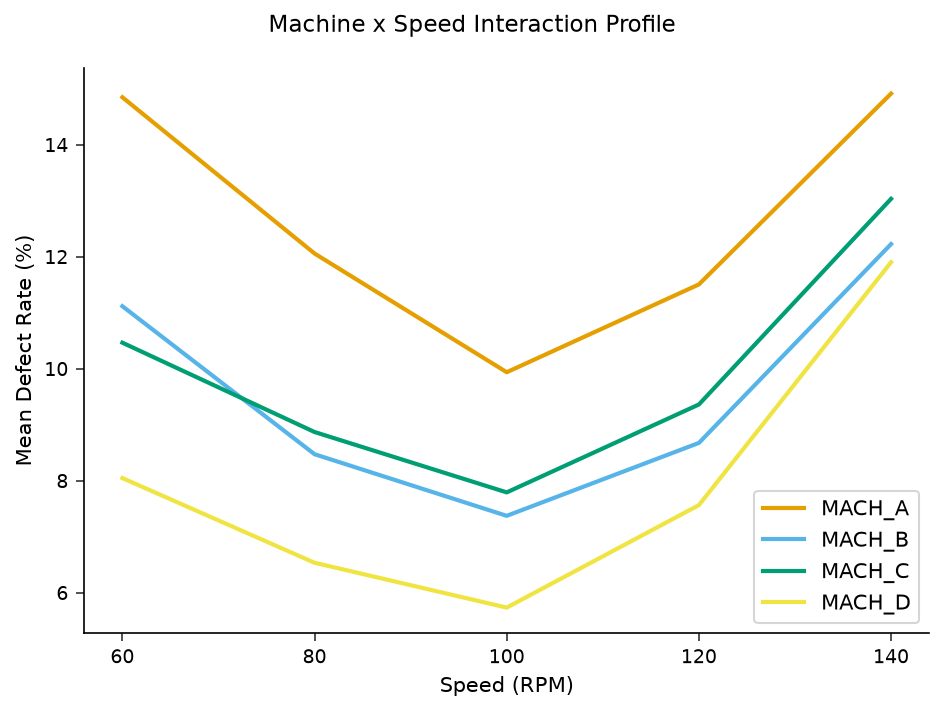

In [3]:
/* --------------------------------------------------------
   Interaction plot: mean defect rate by speed and machine
   -------------------------------------------------------- */
proc means data=work.molding_experiment noprint;
    class machine speed;
    var defect_rate;
    output out=work.cell_means mean=mean_defect;
run;

proc sgplot data=work.cell_means(where=(_type_=3));
    series x=speed y=mean_defect / group=machine
        lineattrs=(thickness=2) markers;
    xaxis label='Speed (RPM)' values=(60 80 100 120 140);
    yaxis label='Mean Defect Rate (%)';
    title 'Machine x Speed Interaction Profile';
run;

---

                                 Defect Rate and Tensile Strength by Machine and Speed                                  

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable           defect_rate
Estimation Method                   REML
Degrees of Freedom Method  Kenward-Roger
Number of Observations               500

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.7751
Residual               3.2638

          Type III Tests of Fixed Effects          

Effect         Num DF    Den DF   F Value    Pr > F
-----------  --------  --------  --------  --------
speed_label         4     492.0    131.51    <.0001

          Fit Statistics          

Statistic                    Value
-----------------------  ---------
-2 Res Log Likelihood    2031.4708
AIC (Smaller is Better)  2045.4707
BIC (Smal

NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


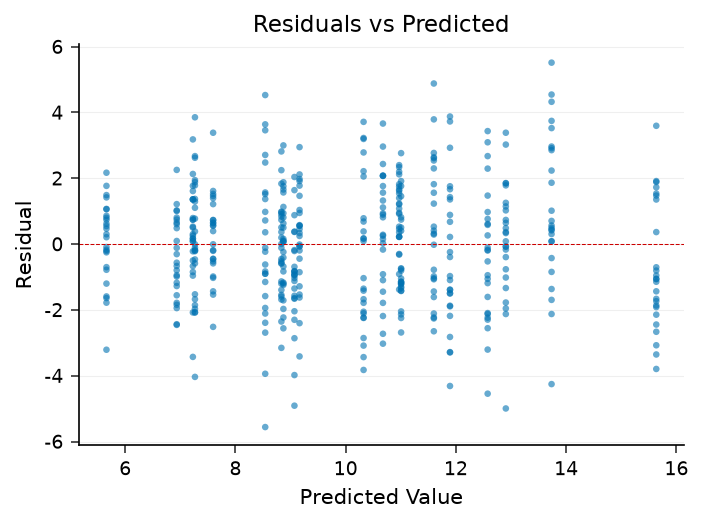

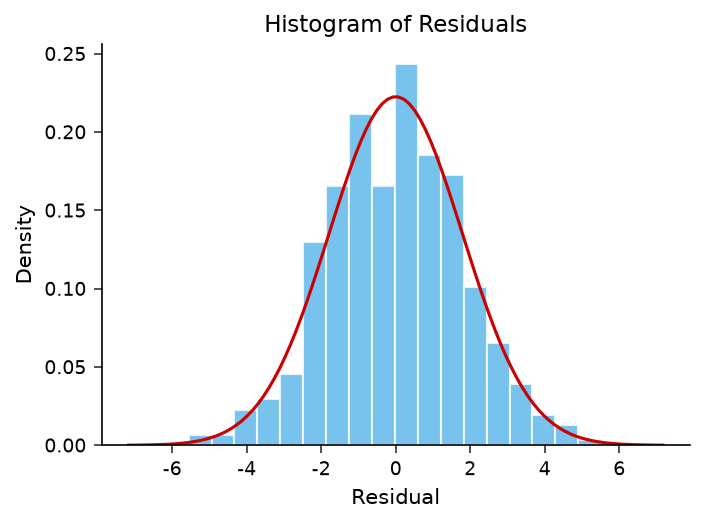

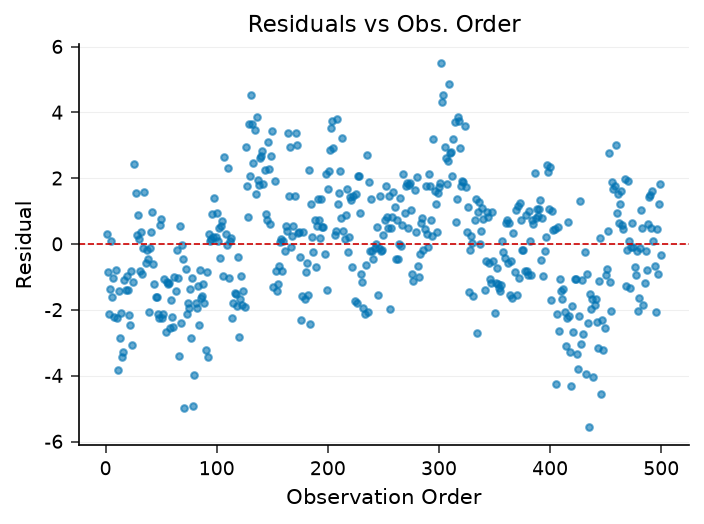

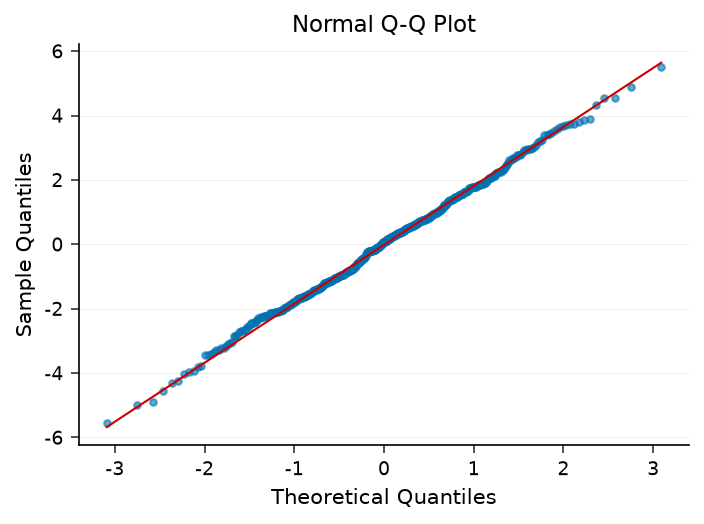

In [4]:
/* --------------------------------------------------------
   Split-plot mixed model analysis
   Machine is random (whole-plot error)
   Speed is fixed (sub-plot factor)
   -------------------------------------------------------- */
proc mixed data=work.molding_experiment method=reml;
    class machine speed_label;
    model defect_rate = speed_label / solution ddfm=kr;
    random machine;
    lsmeans speed_label / adjust=tukey diff cl;
    ods output lsmeans=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    title 'Split-Plot Analysis: Speed Effect on Defect Rate';
run;

In [5]:
/* --------------------------------------------------------
   Identify optimal speed setting
   The ODS OUTPUT LSMeans dataset stores the class level in
   the `treatment` column (the Effect name `speed_label`
   lives in a separate column); keep + rename it on input
   for a clean, labeled report row.
   -------------------------------------------------------- */
proc sort data=work.speed_lsmeans;
    by estimate;
run;

data work.optimal_speed;
    set work.speed_lsmeans(obs=1
        keep=treatment estimate stderr lower upper
        rename=(treatment=speed_label));
    label speed_label = 'Optimal Speed'
          estimate = 'LS Mean Defect Rate'
          lower = '95% CI Lower'
          upper = '95% CI Upper';
run;

proc print data=work.optimal_speed noobs label;
    title 'Recommended Operating Speed for Minimum Defect Rate';
run;

                                  Recommended Operating Speed for Minimum Defect Rate                                   

Optimal Speed  LS Mean Defect Rate  StdErr  95% CI Lower  95% CI Upper
100RPM                      7.7114  0.9881        4.6585       10.7643



NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Variance component decomposition
   -------------------------------------------------------- */
proc print data=work.split_covparms noobs;
    title 'Variance Components: Machine vs Residual';
run;

                                        Variance Components: Machine vs Residual                                        

  COVPARM  ESTIMATE
Intercept    3.7751
Residual     3.2638



NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Interpretation

The split-plot model partitions the defect-rate variability into two strata. The **machine (whole-plot) variance component is 3.78** and the **residual (sub-plot) variance is 3.26**, so machine-to-machine differences account for about **54%** of the total variance (3.7751 / (3.7751 + 3.2638) = 0.536). This substantial between-machine share confirms that machine is a genuine source of process variation and that the split-plot design - rather than a fully randomized analysis - is the correct framework.

The Type III test of the fixed speed effect is highly significant: **F(4, 492) = 131.51, p < .0001**, so RPM setting strongly affects defect rate. The least-squares means trace a clear quadratic response with a minimum at the middle speed:

| Speed | LS-mean defect rate (%) | 95% CI |
|-------|------------------------|--------|
| **100 RPM** | **7.71** | 4.66 - 10.76 |
| 80 RPM | 8.99 | 5.93 - 12.04 |
| 120 RPM | 9.28 | 6.23 - 12.33 |
| 60 RPM | 11.12 | 8.07 - 14.17 |
| 140 RPM | 13.02 | 9.97 - 16.07 |

Tukey-adjusted pairwise comparisons show **100 RPM is significantly lower than every other setting** (adjusted p <= 0.0001 against 80, 120, 60, and 140 RPM). The 80 RPM and 120 RPM settings sit in the middle and do **not** differ from one another (difference 0.29, adjusted p = 0.7814), while 60 RPM and 140 RPM produce the highest defect rates.

**Engineering recommendation:** standardize production at **100 RPM** across all four machines, where the model estimates the lowest defect rate (7.71%). Because the machine variance component (3.78) is comparable in magnitude to the residual variance, follow-up work should also target machine-specific calibration - the interaction profile shows MACH_D running consistently lowest and MACH_A highest at every speed - to close the gap between machines at the chosen 100 RPM setpoint.

---

In [7]:
/* --------------------------------------------------------
   Export speed optimization results for engineering
   -------------------------------------------------------- */
proc export data=work.speed_lsmeans
    outfile='speed_optimization_lsmeans.csv'
    dbms=csv replace;
run;

proc export data=work.split_covparms
    outfile='variance_components.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>